# Vision api

최신 언어 모델은 이미지 입력을 처리하고 분석할 수 있는데, 이를 '비전' 이라고 합니다 . '비전'을 통해 시각적 입력을 분석하고 이미지를 생성할 수 있습니다.

| API                     | 지원되는 사용 사례                                                  |
|-------------------------|---------------------------------------------------------------------|
| Responses API           | 이미지를 분석하여 입력으로 사용하거나, 이미지를 출력으로 생성할 수 있음       |

### 이미지 분석
Vision은 모델이 이미지를 "보고" 이해하는 능력입니다. 이미지에 텍스트가 있으면 모델은 텍스트도 이해할 수 있습니다. 모델은 몇 가지 제약이 있더라도 물체, 모양, 색상, 질감을 포함한 대부분의 시각적 요소를 이해할 수 있습니다.

In [1]:
import os
import openai

from dotenv import load_dotenv
load_dotenv() # read local .env file

True

In [2]:
from openai import OpenAI

client = OpenAI()

Model = "gpt-5-nano"

### URL 전달

<img src="https://api.nga.gov/iiif/a2e6da57-3cd1-4235-b20e-95dcaefed6c8/full/!800,800/0/default.jpg" width=300/>

In [3]:
url = "https://api.nga.gov/iiif/a2e6da57-3cd1-4235-b20e-95dcaefed6c8/full/!800,800/0/default.jpg"

response = client.responses.create(
  model=Model,
  input=[
    {
      "role": "user",
      "content": [
        {"type": "input_text", "text": "이 이미지의 내용을 설명해줘. 한국어로 설명해줘."},
        {
          "type": "input_image",
          "image_url": url,
        },
      ],
    }],
)

print(response.output_text)

다음은 이미지의 내용 설명입니다.

- 주인공: 젊은 여성이 의자에 앉아 있는 초상화입니다.
- 의상: 빨간색과 파란색이 세로로 겹친 스트라이프 상의에 금빛 단추가 줄지어 있고, 흰 칼라와 소매가 보입니다. 아래로 내려온 파란 스커트에는 주황색 점들이 찍혀 있습니다.
- 포즈: 몸은 약간 옆을 향해 돌아섰고, 왼팔은 팔걸이에 기대고 있습니다. 오른손은 무릎 위에 작은 꽃다발을 들고 있습니다.
- 머리와 악세서리: 머리는 짙은 색으로 한쪽에 작은 빨간 리본으로 묶여 있습니다.
- 소품: 작은 꽃다발(흰색 꽃과 초록 잎)이 눈에 띄게 들려 있습니다.
- 배경 및 분위기: 배경은 단색의 민트 색으로 간결하게 처리되어 인물이 강조됩니다. 전반적으로 차분하고 우아한 분위기입니다.
- 화풍 특징: 두툼한 붓질과 뚜렷한 색채 대비가 보이는 인상주의 계열의 표현 방식으로 보입니다.

요약하면, 화려한 색채 대비와 간결한 배경 속에서 차분한 표정의 여성이 의자에 앉아 꽃다발을 들고 있는 초상화입니다.


### Base 64로 인코딩된 이미지 전달

| 항목               | 요구사항                                                                 |
|--------------------|--------------------------------------------------------------------------|
| 지원 파일 형식     | PNG, JPEG, WEBP, GIF |
| 파일 크기 제한     | 이미지당 최대 50MB                                                      |

로컬에 이미지 또는 이미지 세트가 있는 경우 이를 Base 64 인코딩 형식으로 모델에 전달할 수 있습니다. 다음은 이에 대한 실제 예입니다.

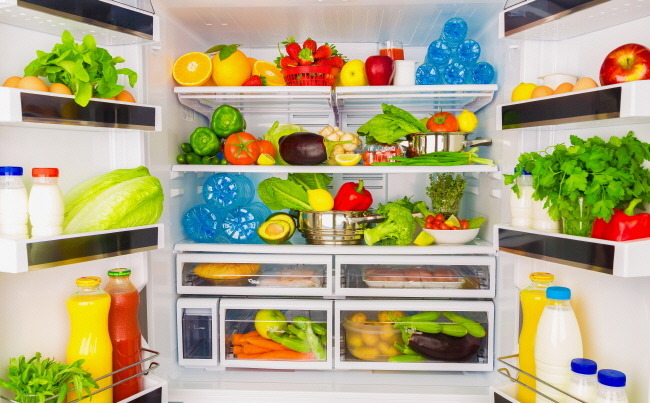

In [4]:
import base64
import requests
from IPython.display import Image, display

# Function to encode the image
def encode_image(image_path):
  with open(image_path, "rb") as image_file:
    return base64.b64encode(image_file.read()).decode('utf-8')

# Path to your image
image_path = "data/냉장고내용물.jpg"

# Getting the base64 string
base64_image = encode_image(image_path)

display(Image(filename=image_path))

In [5]:
response = client.responses.create(
    model=Model,
    input=[
        {
            "role": "user",
            "content": [
                { "type": "input_text", "text": "이 이미지에 대해서 설명해줘?" },
                {
                    "type": "input_image",
                    "image_url": f"data:image/jpeg;base64,{base64_image}",
                },
            ],
        }],
)

print(response.output_text)

사진은 냉장고를 여는 모습으로, 내부가 다양한 과일과 채소로 가득 차 있습니다. 중앙과 상단 선반에 신선한 식재료가 정돈되어 있고, 도어 쪽 선반에도 음료가 깔끔하게 배열되어 있습니다.

주요 특징
- 상단 선반: 오렌지, 레몬 같은 과일과 사과가 한가득 보이고, 빨강/노랑 색감이 화려합니다.
- 중간 선반: 피망, 가지, 상추 같은 채소가 여러 종 섞여 있고, 허브나 작은 채소 바구니도 보입니다.
- 중앙 하단: 투명 서랍에 채소와 과일이 보관되어 있어 내용물이 쉽게 보입니다.
- 도어 선반: 주스 병과 음료병이 정렬되어 있습니다.

전반적으로 신선한 재료가 풍성하고 색상이 선명하게 보이는 정돈된 냉장고 내부예요. 어떤 재료로 요리할지 아이디어가 필요하면 알려 주세요.


### File ID 전달

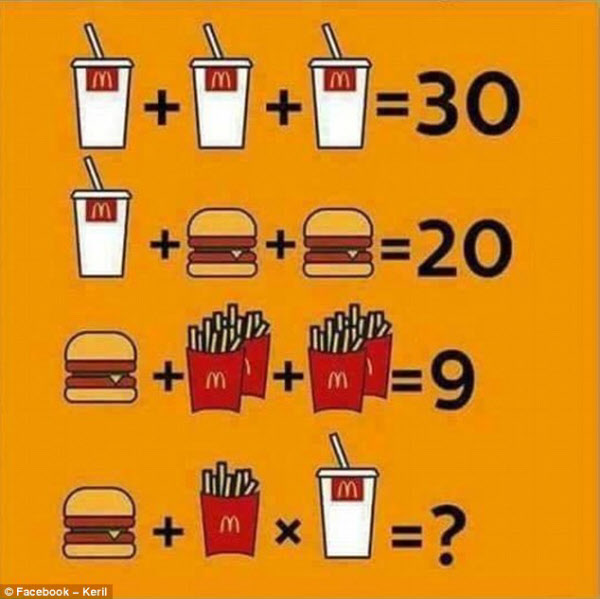

In [7]:
# Path to your image
image_path = "data/수학문제이미지.jpg"

# Getting the base64 string
base64_image = encode_image(image_path)

display(Image(filename=image_path))

In [6]:
# Files API를 사용하여 파일을 생성하는 함수
def create_file(file_path):
  with open(file_path, "rb") as file_content:
    result = client.files.create(
        file=file_content,
        purpose="vision",
    )
    return result.id

# Getting the file ID
file_id = create_file("data/수학문제이미지.jpg")

response = client.responses.create(
    model="gpt-5-nano",
    input=[{
        "role": "user",
        "content": [
            {"type": "input_text", "text": "이 이미지의 내용을 설명해줘."},
            {
                "type": "input_image",
                "file_id": file_id,
            },
        ],
    }],
)

print(response.output_text)

정답은 25예요.

풀이 요약:
- 컵 한 개 = C, 컵 세 개가 30 → 3C = 30 ⇒ C = 10
- 컵 + 햄버거 + 햄버거 = 20 ⇒ 10 + 2B = 20 ⇒ 햄버거 B = 5
- 햄버거 + 프렌즈 + 프렌즈 = 9 ⇒ 5 + 2F = 9 ⇒ 프렌즈 F = 2
- 마지막 식: 햄버거 + 프렌즈 × 컵 = 5 + 2 × 10 = 5 + 20 = 25 (곱셈 우선)

따라서 결과는 25입니다.


### 실습 문제

Vision 기능으로 **웹 이미지 URL**을 분석하세요.

1. 분석할 이미지의 공개 URL을 하나 준비하세요.
2. `input` 에 `input_text`(질문)와 `input_image`(`image_url`)를 함께 구성하세요.
3. 이미지에 무엇이 있는지 한국어로 설명하도록 요청하고 결과를 출력하세요.

### 테스트 입력 예시

- 임의의 풍경/사물 사진 URL → `"이 이미지에 무엇이 보이는지 한국어로 설명해줘."`